# Fastai & PyTorch LSTM Milestone Locator Model

This notebook trains a sequence labeling model using a Bidirectional LSTM to locate the 8 key golf swing milestones in golf videos. 

Unlike tabular classifiers (like XGBoost) which treat every video frame as an independent sample, this recurrent neural network processes the entire video sequence in chronological order, carrying a temporal memory of the swing phases.

We use **Fastai**'s high-level training API to manage learning rate optimization, training loops, and validation metrics with minimal code.

## Step 1: Imports & Environment Setup

We load standard libraries, PyTorch modules, and Fastai's training wrappers. 

> **Note on Python 3.14 Compatibility**:
> Fastai's helper library `fastcore` contains a small dynamic list method (`starmap`) that has compatibility issues on Python 3.14. We dynamically add a short helper patch at the top of the notebook to resolve this out-of-the-box.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Core PyTorch (Neural Network Framework)
import torch
import torch.nn as nn
from torch.utils.data import Dataset

# Fastai (High-Level Training Wrappers)
from fastai.basics import *
from fastai.callback.all import *

# Python 3.14 Compatibility Patch for Fastcore Lists
import itertools
from fastcore.foundation import L
L.starmap = lambda self, f: L(itertools.starmap(f, self))

# Configure project path to access local source files
PROJECT_ROOT = os.path.abspath("../")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

## Step 2: Load the Consolidated Dataset

We load the master dataset generated in our preprocessing step and filter it to keep only golf swing videos (`is_golf == 1`).

We select the **98 base normalized coordinate features** starting with `norm_` (excluding the shifted `_t-5` or `_t+5` features). Because the LSTM processes frames sequentially, it calculates changes over time itself, eliminating the need for sliding window feature columns.

In [2]:
master_dataset_path = os.path.join(PROJECT_ROOT, "data/processed/master_dataset.csv")

print("Loading consolidated master dataset...")
df_full = pd.read_csv(master_dataset_path)

# Filter to keep only golf swings
df = df_full[df_full["is_golf"] == 1].copy()
print(f"Loaded {df['video_id'].nunique()} golf swings with {len(df)} total frames.")

# Extract coordinates: keep features starting with 'norm_' but discard shifted columns
all_features = sorted([c for c in df.columns if c.startswith("norm_")])
base_features = [c for c in all_features if not (c.endswith("t-5") or c.endswith("t+5"))]

print(f"Using {len(base_features)} base coordinate features for LSTM input.")

Loading consolidated master dataset...


/var/folders/4c/nvx1mdln0kl4lvn21s4q6m340000gn/T/ipykernel_91568/3273107257.py:4: DtypeWarning: Columns (0: video_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df_full = pd.read_csv(master_dataset_path)


Loaded 1400 golf swings with 393899 total frames.
Using 66 base coordinate features for LSTM input.


## Step 3: Split Dataset by Video ID (80/10/10)

To prevent data leakage, we perform a **group split** using `video_id`. All frames belonging to a specific video will remain together in either the train, validation, or test split.

In [3]:
unique_vids = df["video_id"].unique()
np.random.seed(42) # Ensure reproducible splits
np.random.shuffle(unique_vids)

n_vids = len(unique_vids)
split_tr = int(n_vids * 0.8)
split_va = int(n_vids * 0.9)

train_vids = unique_vids[:split_tr]
val_vids = unique_vids[split_tr:split_va]
test_vids = unique_vids[split_va:]

print(f"Train videos:      {len(train_vids)}")
print(f"Validation videos: {len(val_vids)}")
print(f"Test videos:       {len(test_vids)}")

Train videos:      1120
Validation videos: 140
Test videos:       140


## Step 4: Define sequence dataset class (`GolfMilestoneDataset`)

Neural networks process sequence batches of uniform shape. Since different videos have different lengths, we pad or truncate sequences to a fixed length of **300 frames** (the 75th percentile of our video lengths):
1. **Input Padding**: Video coordinate sequences shorter than 300 frames are padded with `0.0` at the end.
2. **Label Padding**: Milestone labels (target outputs) for padded frames are filled with `-100`. This is a standard PyTorch convention: `ignore_index=-100` tells the loss function to ignore these frames during gradient calculations.
3. **NaN Filtering**: If MediaPipe failed to detect a golfer for an entire video (yielding NaN values), we skip the sequence entirely to avoid passing corrupted arrays to the network.

In [4]:
class GolfMilestoneDataset(Dataset):
    def __init__(self, df, video_ids, feature_cols, max_len=1280):
        self.sequences = []
        self.labels = []
        self.actual_lengths = []
        
        # Group frames by video
        grouped = df[df['video_id'].isin(video_ids)].groupby('video_id')
        
        for vid_id, group in grouped:
            # Ensure chronological order
            group = group.sort_values('frame_index')
            features = group[feature_cols].values.astype(np.float32)
            
            # Ignore video if it contains any NaN values
            if np.isnan(features).any():
                continue
                
            labels = group['label'].values.astype(np.int64)
            seq_len = len(features)
            self.actual_lengths.append(min(seq_len, max_len))
            
            # Pad or truncate features with zeros to max_len
            if seq_len < max_len:
                pad_f = np.zeros((max_len - seq_len, features.shape[1]), dtype=np.float32)
                features = np.concatenate([features, pad_f], axis=0)
                
                # Pad targets with -100 (ignored by loss functions)
                pad_l = np.full((max_len - seq_len,), -100, dtype=np.int64)
                labels = np.concatenate([labels, pad_l], axis=0)
            else:
                features = features[:max_len]
                labels = labels[:max_len]
                
            self.sequences.append(features)
            self.labels.append(labels)
            
    def __len__(self):
        return len(self.sequences)
        
    def __getitem__(self, idx):
        # Returns a single training sample for Fastai (inputs, targets)
        return (
            torch.tensor(self.sequences[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )
        
    def get_eval_item(self, idx):
        # Returns a sequence along with its original unpadded length for test evaluation
        return (
            torch.tensor(self.sequences[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.long),
            self.actual_lengths[idx]
        )

In [5]:
# Instantiate train, validation, and test datasets
train_dataset = GolfMilestoneDataset(df, train_vids, base_features)
val_dataset = GolfMilestoneDataset(df, val_vids, base_features)
test_dataset = GolfMilestoneDataset(df, test_vids, base_features)

print(f"Total processed clean training videos:   {len(train_dataset)}")
print(f"Total processed clean validation videos: {len(val_dataset)}")
print(f"Total processed clean test videos:       {len(test_dataset)}")

Total processed clean training videos:   1120
Total processed clean validation videos: 140
Total processed clean test videos:       140


## Step 5: Define the Bidirectional LSTM Model

Our model architecture consists of:
1. **Bidirectional LSTM layer**: Processes the sequence in both forward direction (start to finish) and backward direction (finish to start), outputs a combined temporal representation.
2. **Linear Classification Head**: Projects the LSTM outputs into 9 class logits (representing milestone classes $0$ to $8$) for each frame in the sequence.

> **Why transpose the output?**
> Fastai's standard `CrossEntropyLoss` expects temporal input logits to have shape `(batch, classes, sequence_length)` instead of `(batch, sequence_length, classes)`. We transpose the last two dimensions in the forward pass to comply.

In [6]:
class GolfLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_classes=9, num_layers=2):
        super(GolfLSTMModel, self).__init__()
        # 2-layer Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=input_dim, 
            hidden_size=hidden_dim, 
            num_layers=num_layers, 
            batch_first=True,
            bidirectional=True,
            dropout=0.3 if num_layers > 1 else 0.0
        )
        # Map LSTM outputs (hidden_dim * 2 due to bidirectionality) to class logits
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        lstm_out, _ = self.lstm(x) # shape: (batch_size, seq_len, hidden_dim * 2)
        logits = self.fc(lstm_out) # shape: (batch_size, seq_len, num_classes)
        
        # Convert from (batch, seq, classes) to (batch, classes, seq) for Fastai compatibility
        return logits.transpose(1, 2)

## Step 6: Model Training Setup & Execution

1. **Device Setup**: We detect and utilize Apple's Metal Performance Shaders (`mps`) GPU acceleration on Mac, falling back to CPU if unavailable.
2. **Class Imbalance Weights**: Milestone frames (labels 1-8) are extremely rare compared to transition frames (label 0, which accounts for ~97% of frames). We compute inverse-frequency weights from the training set to prevent the model from ignoring the milestones.
3. **Metrics**: We define `frame_accuracy` to monitor frame classification accuracy on validation batches, ensuring we ignore padded frames (`targets != -100`).
4. **Training**: We wrap our datasets in Fastai's `DataLoaders`, define a standard `Learner` and train using the one-cycle policy (`learn.fit_one_cycle()`) with early stopping on validation loss.

In [7]:
# 1. Select hardware device
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Training on device: {device}")

# 2. Calculate inverse-frequency class weights
y_train_flat = df[df['video_id'].isin(train_vids)]['label'].values
class_counts = np.bincount(y_train_flat)
total_samples = len(y_train_flat)
class_weights = total_samples / (len(class_counts) * class_counts)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# 3. Fastai DataLoaders wrap
dls = DataLoaders.from_dsets(train_dataset, val_dataset, bs=32, device=device)

# 4. Frame Accuracy Metric (ignoring -100 padding)
def frame_accuracy(preds, targets):
    pred_labels = torch.argmax(preds, dim=1) # shape: (batch, seq_len)
    mask = targets != -100
    correct = (pred_labels == targets) & mask
    return correct.sum().float() / (mask.sum().float() + 1e-10)

model = GolfLSTMModel(input_dim=len(base_features)).to(device)

# 5. Define Learner
learn = Learner(
    dls,
    model,
    loss_func=nn.CrossEntropyLoss(weight=weights_tensor, ignore_index=-100),
    metrics=[frame_accuracy]
)

# 6. Train using Fastai fit_one_cycle
learn.fit_one_cycle(
    n_epoch=30,
    lr_max=0.001,
    cbs=[EarlyStoppingCallback(monitor='valid_loss', min_delta=0.0, patience=5)]
)

# Save model parameters
torch.save(model.state_dict(), "../models/lstm_phase_model.pt")

Training on device: mps


epoch,train_loss,valid_loss,frame_accuracy,time
0,2.196630,2.189069,0.003718,00:06
1,2.175201,2.124110,0.006811,00:05
2,2.031508,1.644930,0.016763,00:05
3,1.543867,0.789497,0.035322,00:05
4,1.050810,0.498314,0.054951,00:05
5,0.745769,0.429000,0.176346,00:05
6,0.564032,0.378958,0.372653,00:05
7,0.460816,0.332578,0.360820,00:05
8,0.393681,0.305923,0.460813,00:05
9,0.353205,0.314656,0.426744,00:05


No improvement since epoch 11: early stopping


## Step 7: Plot training loss history

<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

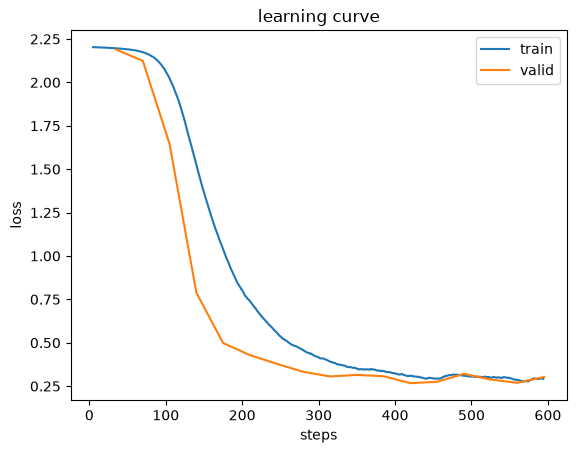

In [8]:
learn.recorder.plot_loss()

## Step 8: Sequence Evaluation & Peak Finding

To locate milestone frame indices, we feed the sequence through the model to retrieve predicted frame probabilities.

For each milestone class $1$ to $8$, we locate the **frame index that has the highest predicted probability** (peak activation) for that class within the unpadded video length.

We evaluate this sequence prediction by calculating the **Mean Absolute Error (MAE)** in frames between the predicted frame and the true milestone frame.

In [9]:
model.eval() # Set model to evaluation mode

all_errors = []

with torch.no_grad():
    for idx in range(len(test_dataset)):
        # Retrieve test sequence and unpadded length
        x_seq, y_seq, length = test_dataset.get_eval_item(idx)
        
        # Add batch dimension and send to hardware device
        x_batch = x_seq.unsqueeze(0).to(device) 
        logits = model(x_batch) # shape: (1, 9, seq_len)
        
        # Apply softmax to convert output logits to probabilities
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy() # shape: (9, seq_len)
        y_seq = y_seq.numpy()
        
        # Slice padding off the predictions and labels
        v_probs = probs[:, :length].T # shape: (length, 9)
        v_labels = y_seq[:length]
        
        # 1. Retrieve true milestone indices
        true_indices = []
        for c in range(1, 9):
            idx_matches = np.where(v_labels == c)[0]
            if len(idx_matches) > 0:
                true_indices.append(int(idx_matches[0]))
            else:
                true_indices.append(-1)
                
        if -1 in true_indices:
            # Skip if any milestone is missing in labels
            continue
            
        # 2. Predict milestone indices using argmax peak-finding
        pred_indices = []
        for c in range(1, 9):
            # Find the frame index that maximizes the probability of milestone class c
            pred_frame = np.argmax(v_probs[:, c])
            pred_indices.append(int(pred_frame))
            
        # 3. Calculate errors
        abs_errors = [abs(p - t) for p, t in zip(pred_indices, true_indices)]
        all_errors.append(abs_errors)

all_errors = np.array(all_errors)
mae_per_milestone = np.mean(all_errors, axis=0)
print(f"Evaluated peak errors for {len(all_errors)} test sequences.")

Evaluated peak errors for 139 test sequences.


## Step 9: Print Mean Absolute Errors per Milestone

We display the final MAE (in frames) on the test set for all 8 milestones.

In [10]:
m_names = {
    1: 'Address', 2: 'Toe-up (Backswing)', 3: 'Mid-backswing',
    4: 'Top of Backswing', 5: 'Mid-downswing', 6: 'Impact',
    7: 'Mid-follow-through', 8: 'Finish'
}

summary_rows = []
for c in range(1, 9):
    summary_rows.append({
        "Milestone": f"{c}: {m_names[c]}",
        "LSTM MAE (frames)": f"{mae_per_milestone[c-1]:.2f}"
    })

df_summary = pd.DataFrame(summary_rows)
print(df_summary)
print(f"\nOverall Mean Absolute Error: {np.mean(mae_per_milestone):.2f} frames")

               Milestone LSTM MAE (frames)
0             1: Address             11.99
1  2: Toe-up (Backswing)              2.46
2       3: Mid-backswing              4.82
3    4: Top of Backswing              5.03
4       5: Mid-downswing              4.19
5              6: Impact              1.82
6  7: Mid-follow-through              2.31
7              8: Finish              8.09

Overall Mean Absolute Error: 5.09 frames
